In [1]:
import pandas as pd

df = pd.read_csv("./single_independent_variable_linear.csv")
df

,x,y
0,99.504842,159.464415
1,44.662766,50.508179
2,66.631337,91.677570
3,74.663878,121.276874
4,57.554853,77.660511
...,...,...
375,187.856720,314.745930
376,54.705039,74.161177
377,137.863407,222.073346
378,128.667926,226.704162


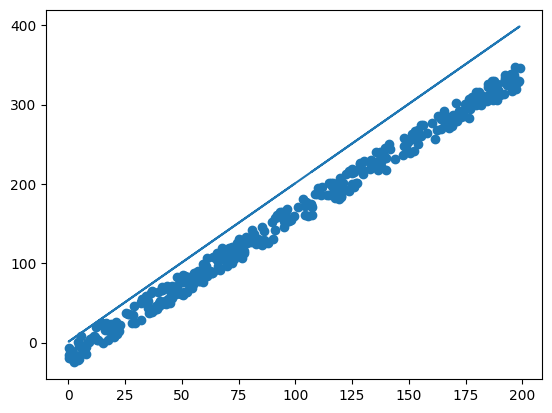

In [2]:
import matplotlib.pyplot as plt

plt.scatter(df["x"], df["y"])  # scatter points

plt.plot(df["x"], 2 * df["x"] + 1,)  # line y = 2x + 1

plt.show()

In [3]:
X = df.values[:,:-1]
y = df.values[:,-1]

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
fit = model.fit(X,y)

m = fit.coef_.flatten()
b = fit.intercept_.flatten()
print("m = {0}".format(m))
print("b = {0}".format(b))


m = [1.7867224]
b = [-16.51923513]


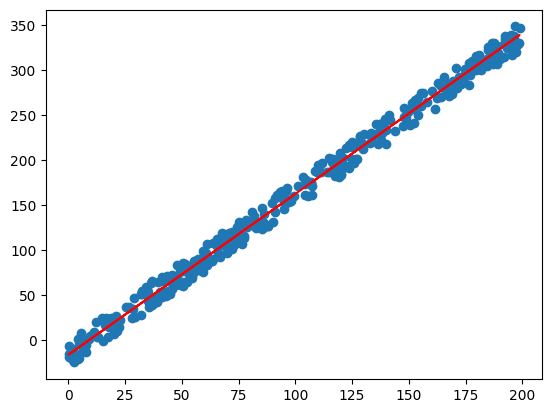

In [16]:
import matplotlib.pyplot as plt

# show in chart
plt.scatter(X, y) # scatterplot
plt.plot(X, m*X+b,color="red") # line
plt.show()


In [6]:
fit.coef_.flatten()

array([1.7867224])

In [7]:
fit.intercept_

np.float64(-16.5192351312364)

# Calculating the residuals

![](residuals-squared.png)

In [8]:
import pandas as pd

points = pd.read_csv("./single_independent_variable_linear.csv").itertuples()

# Test with a given line
m = 1.93939
b = 4.73333
sum_of_squares = 0.0


for p in points:
    y_predict = m * p.x + b
    residual = (y_predict - p.y) ** 2
    sum_of_squares += residual
print("sum of squares = {}".format(sum_of_squares))


sum of squares = 563048.6639424213


[](!residuals-squared.png)

# Closed-Form Solution for Simple Linear Regression

The slope:

$$
m=\frac{n\sum xy-\sum x\sum y}
{n\sum x^2-(\sum x)^2}
$$

The intercept:

$$
b=\frac{\sum y}{n}-m\frac{\sum x}{n}
$$

The regression line:

$$
y = mx + b
$$

In [9]:
import pandas as pd

points = list(pd.read_csv("./single_independent_variable_linear.csv").itertuples())

n = len(points)

sum_x = sum(p.x for p in points)
sum_y = sum(p.y for p in points)
sum_xy = sum(p.x * p.y for p in points)
sum_x2 = sum(p.x ** 2 for p in points)

m = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)

b = (sum_y / n) - m * (sum_x / n)

print("m =", m)
print("b =", b)

m = 1.7867223967956563
b = -16.519235131236172


# Linear Regression Using the Normal Equation

We want to fit a line:

$$
\hat{y} = mx + c
$$

where:

- \(m\) is the slope
- \(c\) is the intercept

## Input data

The input vector is:

$$
X =
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{bmatrix}
$$

The output vector is:

$$
y =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
$$

## Add a column of ones

To include the intercept, we create a new matrix:

$$
X_1 =
\begin{bmatrix}
x_1 & 1 \\
x_2 & 1 \\
\vdots & \vdots \\
x_n & 1
\end{bmatrix}
$$

This matches the code:

```python
X_1 = np.vstack([X, np.ones(len(X))]).T
```

## Parameter vector

The coefficients are:

$$
\beta =
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

So the model becomes:

$$
\hat{y} = X_1 \beta
$$

## Normal equation

To find the best values of \(m\) and \(c\), we use:

$$
\beta = (X_1^T X_1)^{-1} X_1^T y
$$

This matches the code:

```python
b = np.linalg.inv(X_1.T @ X_1) @ (X_1.T @ y)
```

## Result

The result is:

$$
b =
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

So:

- `b[0]` is the slope
- `b[1]` is the intercept

In [37]:
import pandas as pd
import numpy as np

df = pd.read_csv("./single_independent_variable_linear.csv")

X = df.values[:, :-1].flatten()
y = df.values[:, -1]

# Add column of ones for intercept
X_1 = np.vstack([X, np.ones(len(X))]).T

# Normal equation
b = np.linalg.inv(X_1.T @ X_1) @ (X_1.T @ y)

print(b)

[  1.7867224  -16.51923513]


# Linear Regression Using QR Decomposition

We want to fit the linear model:

$$
\hat{y} = mx + c
$$

where:

- \(m\) is the slope
- \(c\) is the intercept

## Design Matrix

The input data is transformed into the design matrix:

$$
X_1 =
\begin{bmatrix}
x_1 & 1 \\
x_2 & 1 \\
\vdots & \vdots \\
x_n & 1
\end{bmatrix}
$$

using:

```python
X_1 = np.vstack([X, np.ones(len(X))]).T
```

The target vector is:

$$
Y =
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix}
$$

The linear regression model can be written as:

$$
Y = X_1 \beta
$$

where

$$
\beta =
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

contains the unknown coefficients.

## QR Decomposition

Instead of computing the coefficients using the Normal Equation, we decompose the design matrix as:

$$
X_1 = QR
$$

where:

- \(Q\) is an orthogonal matrix

$$
Q^TQ = I
$$

- \(R\) is an upper triangular matrix

$$
R =
\begin{bmatrix}
r_{11} & r_{12} \\
0 & r_{22}
\end{bmatrix}
$$

This decomposition is performed with:

```python
Q, R = qr(X_1)
```

## Solving for the Coefficients

Starting from

$$
Y = X_1 \beta
$$

and substituting

$$
X_1 = QR
$$

gives

$$
Y = QR\beta
$$

Multiplying both sides by \(Q^T\):

$$
Q^T Y = Q^T QR\beta
$$

Since

$$
Q^TQ = I
$$

we obtain

$$
Q^T Y = R\beta
$$

or

$$
R\beta = Q^T Y
$$

Finally, multiplying by \(R^{-1}\):

$$
\beta = R^{-1}Q^T Y
$$

This is implemented as:

```python
b = inv(R).dot(Q.T).dot(Y)
```

## Result

The coefficient vector is:

$$
b =
\begin{bmatrix}
m \\
c
\end{bmatrix}
$$

where:

- `b[0]` is the slope
- `b[1]` is the intercept

QR decomposition produces the same regression coefficients as the Normal Equation but is generally more numerically stable because it avoids computing

$$
(X_1^T X_1)^{-1}
$$

directly.

In [39]:
# solving using QR composition
import pandas as pd
from numpy.linalg import qr, inv
import numpy as np
# Import points
df = pd.read_csv("./single_independent_variable_linear.csv")
# Extract input variables (all rows, all columns but last column)
X = df.values[:, :-1].flatten()
# Add placeholder "1" column to generate intercept
X_1 = np.vstack([X, np.ones(len(X))]).transpose()
# Extract output column (all rows, last column)
Y = df.values[:, -1]
# calculate coefficents for slope and intercept
# using QR decomposition
Q, R = qr(X_1)
b = inv(R).dot(Q.transpose()).dot(Y)
b

array([  1.7867224 , -16.51923513])

In [11]:
# Using gradient descent to find the minimum of a parabola
import random 

def f(x):
    return (x-3) **2 + 4 
def dx_f(x):
    return 2 * (x-3)

L = 0.001
iterations = 100_000
x = random.randint(-15,15)
for i in range(iterations):
    dx = dx_f(x)
    x -= L * dx

print(f"x = {x}") # the actual minimum is 3
    

x = 2.999999999999889


In [16]:
import pandas as pd
# Import points from CSV
points = list(pd.read_csv("./single_independent_variable_linear.csv").itertuples())
# Building the model
m = 0.0
b = 0.0
# The learning Rate
L = .0001
# The number of iterations
iterations = 100_000
n = float(len(points)) # Number of elements in X
# Perform Gradient Descent
for i in range(iterations):
    # slope with respect to m
    D_m = sum(2 * p.x * ((m * p.x + b) - p.y) for p in points)
    # slope with respect to b
    D_b = sum(2 * ((m * p.x + b) - p.y) for p in points)
    # update m and b
    print(D_m)
    m -= L * D_m
    b -= L * D_b
print("y = {0}x + {1}".format(m, b))
# y = 1.9393939393939548x + 4.733333333333227

-16857685.16023141
17068214282.28292
-17281397385431.016
1.7497243135080634e+16
-1.771578481186011e+19
1.7937056088046784e+22
-1.8161091056510449e+25
1.8387924235942965e+28
-1.8617590576176852e+31
1.8850125463570253e+34
-1.9085564726459178e+37
1.9323944640677813e+40
-1.9565301935147822e+43
1.9809673797537433e+46
-2.0057097879991204e+49
2.0307612304931358e+52
-2.0561255670931617e+55
2.081806705866431e+58
-2.1078086036921857e+61
2.1341352668713404e+64
-2.1607907517437623e+67
2.18777916531326e+70
-2.2151046658803814e+73
2.2427714636831116e+76
-2.2707838215455754e+79
2.2991460555348407e+82
-2.3278625356259273e+85
2.3569376863751206e+88
-2.386375987601694e+91
2.4161819750781488e+94
-2.4463602412290715e+97
2.476915435838723e+100
-2.5078522667674663e+103
2.539175500677137e+106
-2.570889963765481e+109
2.6030005425097583e+112
-2.635512184419642e+115
2.6684298987995133e+118
-2.7017587575202833e+121
2.735503895800853e+124
-2.7696705129993336e+127
2.8042638734141477e+130
-2.83928930709514e+133
2.8

In [44]:
# Solving linear regression using SymP
import pandas as pd
from sympy import symbols, Sum, diff, Function, lambdify
df = pd.read_csv("./single_independent_variable_linear.csv")

x_mean, x_std = df["x"].mean(), df["x"].std()
y_mean, y_std = df["y"].mean(), df["y"].std()

# normalize
df["x"] = (df["x"] - x_mean) / x_std
df["y"] = (df["y"] - y_mean) / y_std

points = list(df.itertuples())
m,b,i,n = symbols("m b i n")
x, y = symbols("x y",cls=Function)

sum_of_squares = Sum((m * x(i) + b - y(i)) ** 2,(i,0,n))

dm = diff(sum_of_squares, m).subs(n,len(points)-1).doit()\
    .replace(x,lambda i: points[i].x)\
    .replace(y,lambda i: points[i].y)

db = diff(sum_of_squares,b).subs(n,len(points)-1).doit()\
    .replace(x,lambda i: points[i].x)\
    .replace(y,lambda i: points[i].y)

dm = lambdify([m,b],dm)
db = lambdify([m,b],db)

# Building the model
m = 0.0
b = 0.0
# The learning Rate
L = 0.0001
# The number of iterations
iterations = 100_000
# Perform Gradient Descent
for i in range(iterations):
    if i % 10_000 == 0:
        print(f"iter {i}: m={m:.4f}, b={b:.4f}")
    # update m and b
    m -= dm(m,b) * L
    b -= db(m,b) * L
print("y = {0}x + {1}".format(m, b))
# y = 1.939393939393954x + 4.733333333

iter 0: m=0.0000, b=0.0000
iter 10000: m=0.9967, b=-0.0000
iter 20000: m=0.9967, b=-0.0000
iter 30000: m=0.9967, b=-0.0000
iter 40000: m=0.9967, b=-0.0000
iter 50000: m=0.9967, b=-0.0000
iter 60000: m=0.9967, b=-0.0000
iter 70000: m=0.9967, b=-0.0000
iter 80000: m=0.9967, b=-0.0000
iter 90000: m=0.9967, b=-0.0000
y = 0.996664775081035x + -1.6049402627121055e-17


,x,y
count,380.000000,380.000000
mean,99.529904,161.313073
std,58.630171,105.106393
min,0.119766,-25.030104
25%,51.175903,73.152208
50%,93.682737,153.861221
75%,151.626054,256.867646
max,198.796353,348.045327
